# SHAP 기반 XAI 분석

학습된 LightGBM 모델(`scb_model_v1.pkl`)을 로드하여 개별 입력에 대한 SHAP 값을 계산하고,
S등급 산출 근거를 시각화합니다.

**목적**
- 모델이 어떤 피처를 기준으로 등급을 결정하는지 확인
- 개별 사용자에 대한 설명 가능성 검증
- 추후 LLM(Gemini)을 통한 자연어 변환의 입력 데이터 형태 확인

**SHAP 값 해석**
- 양수: 해당 피처가 예측 등급 방향으로 기여 (등급 상승에 긍정적)
- 음수: 해당 피처가 예측 등급 반대 방향으로 작용 (등급 하락에 기여)

In [6]:
import sys
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import shap
import matplotlib.pyplot as plt
import matplotlib

# 한글 폰트 설정 (macOS)
matplotlib.rcParams['font.family'] = 'AppleGothic'
matplotlib.rcParams['axes.unicode_minus'] = False

# 프로젝트 루트 경로 설정
PROJECT_ROOT = Path('../../')
sys.path.insert(0, str(PROJECT_ROOT))

from research.data_preprocessing import preprocess, GRADE_ORDER

print('설정 완료')

설정 완료


In [7]:
# ── 1. 모델 및 데이터 로드 ──────────────────────────────────

MODEL_PATH = PROJECT_ROOT / 'models' / 'scb_model_v1.pkl'
DATA_PATH = PROJECT_ROOT / 'data' / 's_input_feature_40k.csv'

# 모델 로드
with open(MODEL_PATH, 'rb') as f:
    model = pickle.load(f)
print(f'모델 로드 완료: {MODEL_PATH}')
print(f'최적 트리 수: {model.best_iteration_}')

# 데이터 전처리
X_train, X_val, X_test, y_train, y_val, y_test, le = preprocess(DATA_PATH)
print(f'\nTest set shape: {X_test.shape}')
print(f'피처 목록 ({len(X_test.columns)}개): {list(X_test.columns)}')

모델 로드 완료: ../../models/scb_model_v1.pkl
최적 트리 수: 219

Test set shape: (6000, 31)
피처 목록 (31개): ['business_age_months', 'quarterly_revenue_growth_rate', 'annual_revenue_growth_rate', 'revenue_vs_industry_avg_ratio', 'avg_monthly_transaction_3m', 'avg_monthly_transaction_6m', 'avg_monthly_transaction_12m', 'days_since_last_transaction', 'max_inactive_days', 'online_platform_activity_index', 'revenue_growth_per_employee_3m', 'revenue_growth_per_employee_6m', 'revenue_growth_per_employee_12m', 'revenue_growth_per_business_age_3m', 'revenue_growth_per_business_age_6m', 'revenue_growth_per_business_age_12m', 'online_accessibility_score', 'is_near_subway', 'commercial_saturation_score', 'is_traditional_market', 'commercial_trend', 'industry_trend', 'review_rating', 'review_count', 'delivery_rating', 'delivery_order_count', 'positive_review_ratio', 'has_online_reservation', 'owner_experience_years', 'employee_count', 'has_sns']


In [8]:
# ── 2. SHAP TreeExplainer 초기화 ─────────────────────────────

explainer = shap.TreeExplainer(model)
print('TreeExplainer 초기화 완료')

# Test set 전체에 대한 SHAP 값 계산 (시간 소요 가능)
# 샘플 500개로 제한하여 빠르게 확인
SAMPLE_SIZE = 500
X_sample = X_test.iloc[:SAMPLE_SIZE]
y_sample = y_test.iloc[:SAMPLE_SIZE]

print(f'SHAP 값 계산 중 (샘플 {SAMPLE_SIZE}건)...')
shap_values = explainer.shap_values(X_sample)
print(f'SHAP 값 계산 완료')
print(f'shap_values 구조: {len(shap_values)}개 클래스, 각 shape: {shap_values[0].shape}')

TreeExplainer 초기화 완료
SHAP 값 계산 중 (샘플 500건)...
SHAP 값 계산 완료
shap_values 구조: 500개 클래스, 각 shape: (31, 10)


## 3. 전체 피처 중요도 (Global Explanation)

전체 샘플에 대한 SHAP 값의 평균 절댓값으로 피처 중요도를 확인합니다.

X_sample 컬럼 개수: 31
추출된 SHAP 배열의 구조(Shape): (500, 31, 10)
최종 계산된 shap_abs_mean의 길이: 31
[SHAP 기반 전체 피처 중요도 (상위 15개)]


,feature,mean_abs_shap
9,online_platform_activity_index,0.687043
28,owner_experience_years,0.446527
30,has_sns,0.395432
1,quarterly_revenue_growth_rate,0.356478
3,revenue_vs_industry_avg_ratio,0.344761
16,online_accessibility_score,0.321457
2,annual_revenue_growth_rate,0.290493
20,commercial_trend,0.232310
23,review_count,0.224627
0,business_age_months,0.193122


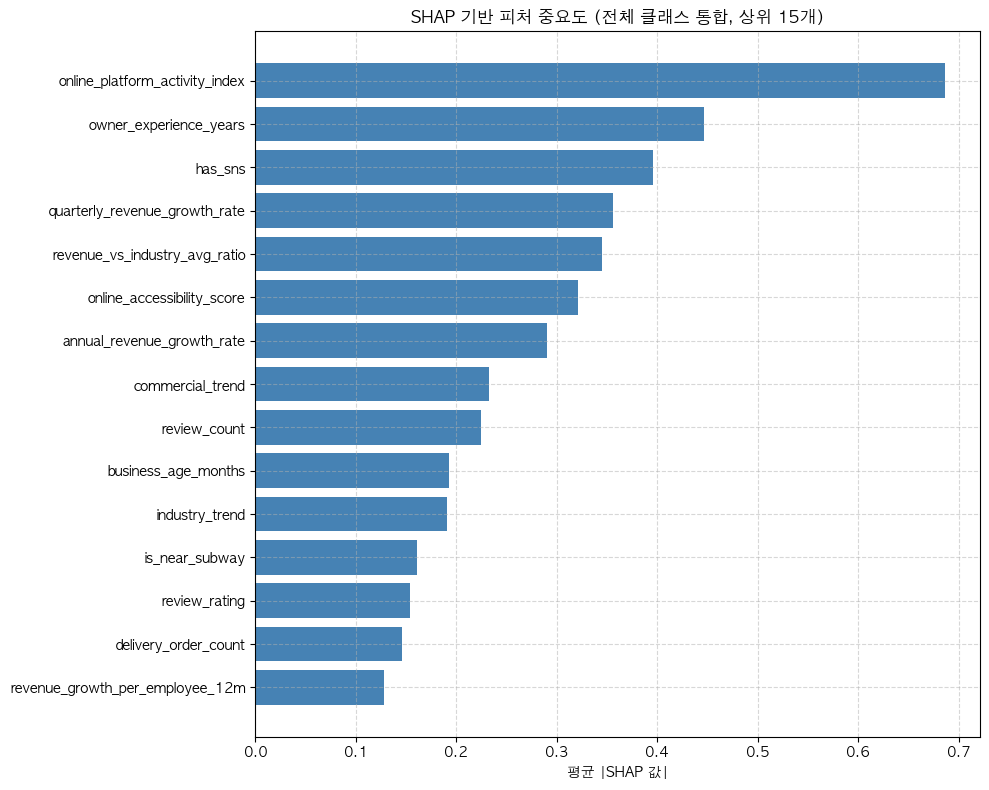

In [9]:
# ── 3. 전체 피처 중요도 (모든 클래스 통합) ────────────────────

# 1. shap_values가 Explanation 객체인 경우 내부의 원래 numpy 배열을 추출
if isinstance(shap_values, shap.Explanation):
    shap_raw = shap_values.values
elif isinstance(shap_values, list):
    shap_raw = np.array(shap_values)
else:
    shap_raw = shap_values

# [디버깅용] 차원 확인 (에러 발생 시 추적을 위해 프린트)
print(f"X_sample 컬럼 개수: {len(X_sample.columns)}")
print(f"추출된 SHAP 배열의 구조(Shape): {shap_raw.shape}")

# 2. SHAP 배열의 구조에 따라 올바른 축(Axis)으로 평균 계산
# 절대값을 먼저 취함
abs_shap = np.abs(shap_raw)

if abs_shap.ndim == 3:
    # Case A: (클래스, 샘플, 피처) 구조인 경우 -> 클래스(0)와 샘플(1) 축에 대해 평균
    if abs_shap.shape[2] == len(X_sample.columns):
        shap_abs_mean = abs_shap.mean(axis=(0, 1))
    # Case B: (샘플, 피처, 클래스) 구조인 경우 -> 샘플(0)과 클래(2) 축에 대해 평균
    elif abs_shap.shape[1] == len(X_sample.columns):
        shap_abs_mean = abs_shap.mean(axis=(0, 2))
    else:
        # 그 외의 경우 안전하게 3번째 차원이 피처라고 가정하고 평균
        shap_abs_mean = abs_shap.mean(axis=0).mean(axis=0)
elif abs_shap.ndim == 2:
    # Case C: (샘플, 피처) 구조인 경우 (이진 분류나 회귀) -> 샘플(0) 축에 대해 평균
    shap_abs_mean = abs_shap.mean(axis=0)
else:
    shap_abs_mean = abs_shap

print(f"최종 계산된 shap_abs_mean의 길이: {len(shap_abs_mean)}")

# 3. 피처 중요도 DataFrame 생성
importance_df = pd.DataFrame({
    'feature': X_sample.columns.tolist(),
    'mean_abs_shap': shap_abs_mean
}).sort_values('mean_abs_shap', ascending=False)

print('[SHAP 기반 전체 피처 중요도 (상위 15개)]')
display(importance_df.head(15))

# 시각화
fig, ax = plt.subplots(figsize=(10, 8))
top15 = importance_df.head(15)
ax.barh(top15['feature'][::-1], top15['mean_abs_shap'][::-1], color='steelblue')
ax.set_xlabel('평균 |SHAP 값|')
ax.set_title('SHAP 기반 피처 중요도 (전체 클래스 통합, 상위 15개)')
ax.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

## 4. 개별 샘플 설명 (Local Explanation)

특정 사용자 1명에 대해 S등급이 왜 그렇게 산출되었는지 설명합니다.
이 형태가 추후 LLM에 전달되어 자연어로 변환됩니다.

In [10]:
# ── 4. 개별 샘플 SHAP 설명 ───────────────────────────────────

# 샘플 1건 선택
sample_idx = 0
sample_input = X_sample.iloc[[sample_idx]]
sample_true_grade = GRADE_ORDER[y_sample.iloc[sample_idx]]

# 예측
predicted_proba = model.predict_proba(sample_input)[0]
predicted_class = int(np.argmax(predicted_proba))
predicted_grade = GRADE_ORDER[predicted_class]

print(f'[샘플 #{sample_idx}]')
print(f'  실제 등급: {sample_true_grade}')
print(f'  예측 등급: {predicted_grade} (확률: {predicted_proba[predicted_class]:.3f})')
print()

# 예측 클래스 기준 SHAP 값
sample_shap = shap_values[predicted_class][sample_idx]

# 상위 기여 변수 추출 (상위 10개)
top_n = 10
top_indices = np.argsort(np.abs(sample_shap))[::-1][:top_n]

print(f'[예측 등급 {predicted_grade}에 대한 상위 {top_n}개 기여 변수]')
print(f'{"피처명":<45} {"SHAP 값":>10} {"방향":>6} {"실제값":>12}')
print('-' * 80)
for idx in top_indices:
    name = X_sample.columns[idx]
    sv = sample_shap[idx]
    direction = '↑ 긍정' if sv > 0 else '↓ 부정'
    value = sample_input.iloc[0, idx]
    print(f'{name:<45} {sv:>+10.4f} {direction:>6} {str(value):>12}')

[샘플 #0]
  실제 등급: S4
  예측 등급: S6 (확률: 0.455)

[예측 등급 S6에 대한 상위 10개 기여 변수]
피처명                                               SHAP 값     방향          실제값
--------------------------------------------------------------------------------
quarterly_revenue_growth_rate                    +0.5524   ↑ 긍정        14.24
days_since_last_transaction                      -0.5461   ↓ 부정            0
business_age_months                              +0.5153   ↑ 긍정           36
avg_monthly_transaction_12m                      -0.3966   ↓ 부정  16279535.23
max_inactive_days                                -0.2553   ↓ 부정            4
annual_revenue_growth_rate                       +0.2218   ↑ 긍정        32.23
avg_monthly_transaction_6m                       -0.2194   ↓ 부정  15578682.63
online_platform_activity_index                   -0.1751   ↓ 부정         56.6
revenue_vs_industry_avg_ratio                    +0.0652   ↑ 긍정         1.46
avg_monthly_transaction_3m                       +0.0145   ↑ 긍정  16660807.35

/Users/yeong/Documents/wooriFISA/SoFit/SoFit-AI/.venv/lib/python3.10/site-packages/shap/plots/_waterfall.py:279: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  text_bbox = txt_obj.get_window_extent(renderer=renderer)
/Users/yeong/Documents/wooriFISA/SoFit/SoFit-AI/.venv/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8722 (\N{MINUS SIGN}) missing from font(s) AppleGothic.
  fig.canvas.print_figure(bytes_io, **kw)


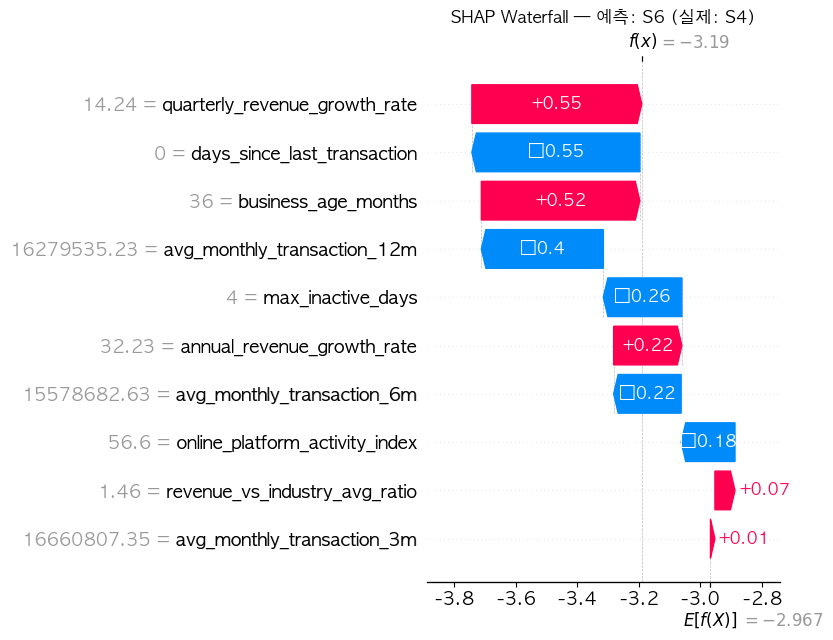

In [11]:
# ── 5. Waterfall Plot (개별 샘플 시각화) ──────────────────────

# shap.Explanation 객체 생성
explanation = shap.Explanation(
    values=sample_shap,
    base_values=explainer.expected_value[predicted_class],
    data=sample_input.values[0],
    feature_names=list(X_sample.columns),
)

plt.figure(figsize=(12, 8))
shap.plots.waterfall(explanation, max_display=15, show=False)
plt.title(f'SHAP Waterfall — 예측: {predicted_grade} (실제: {sample_true_grade})')
plt.tight_layout()
plt.show()

피처 값 개수 (Features length): 31
SHAP 값 개수 (SHAP values length): 31


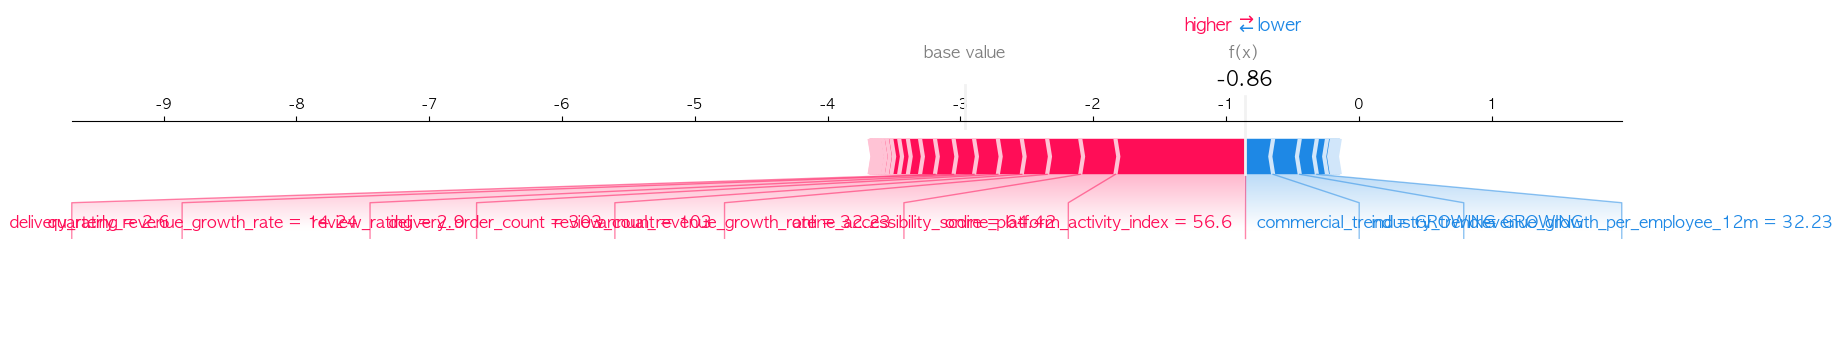

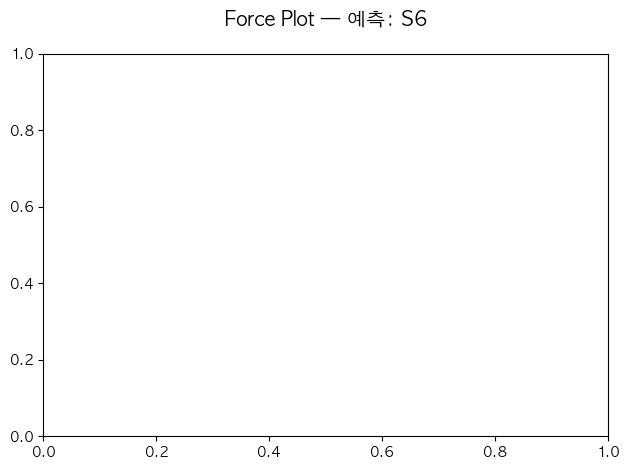

In [13]:
# ── 6. Force Plot (개별 샘플) ─────────────────────────────────
import shap
import numpy as np
import matplotlib.pyplot as plt

# [설정] 그리려는 샘플의 인덱스 지정 (예: X_sample의 0번째 샘플인 경우)
sample_idx = 0 

# 1. shap_values의 타입과 구조에 따라 '특정 샘플' + '특정 클래스'의 1차원 SHAP 배열 추출
if isinstance(shap_values, shap.Explanation):
    # Explanation 객체인 경우
    raw_shap = shap_values.values
    if raw_shap.ndim == 3:
        if raw_shap.shape[2] == len(X_sample.columns): # (클래스, 샘플, 피처)
            sample_shap = raw_shap[predicted_class, sample_idx, :]
        else: # (샘플, 피처, 클래스)
            sample_shap = raw_shap[sample_idx, :, predicted_class]
    else:
        sample_shap = raw_shap[sample_idx]
        
elif isinstance(shap_values, list):
    # 리스트 형태인 경우: shap_values[클래스][샘플_인덱스]
    sample_shap = shap_values[predicted_class][sample_idx]
    
else:
    # 일반 NumPy 배열인 경우
    if shap_values.ndim == 3:
        if shap_values.shape[2] == len(X_sample.columns): # (클래스, 샘플, 피처)
            sample_shap = shap_values[predicted_class, sample_idx, :]
        else: # (샘플, 피처, 클래스)
            sample_shap = shap_values[sample_idx, :, predicted_class]
    else:
        sample_shap = shap_values[sample_idx]

# [디버깅] 두 배열의 길이가 일치하는지 최종 확인
print(f"피처 값 개수 (Features length): {len(sample_input.values[0])}")
print(f"SHAP 값 개수 (SHAP values length): {len(sample_shap)}")

# 2. Force Plot 시각화
shap.initjs()
shap.force_plot(
    explainer.expected_value[predicted_class],
    sample_shap,  # 정제된 1차원 배열 전달
    sample_input.values[0],
    feature_names=list(X_sample.columns),
    matplotlib=True,
)
plt.title(f'Force Plot — 예측: {predicted_grade}', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

## 7. LLM 입력용 SHAP 데이터 형태 확인

BE에서 LLM(Gemini)에 전달할 SHAP 결과의 구조를 확인합니다.
이 형태가 `PredictResponse.shap_features`로 반환됩니다.

In [14]:
# ── 7. 서빙 API 응답 형태 시뮬레이션 ─────────────────────────

# serving/explainer.py와 동일한 로직으로 상위 5개 추출
SHAP_TOP_N = 5

top_indices_api = np.argsort(np.abs(sample_shap))[::-1][:SHAP_TOP_N]

shap_features_for_llm = []
for idx in top_indices_api:
    name = X_sample.columns[idx]
    shap_features_for_llm.append({
        'feature_name': name,
        'shap_value': round(float(sample_shap[idx]), 6),
        'feature_value': sample_input.iloc[0, idx],
    })

# API 응답 형태
api_response = {
    'user_id': 12345,
    's_grade': predicted_grade,
    'shap_features': shap_features_for_llm,
}

print('[서빙 API 응답 형태 (PredictResponse)]')
print()
import json
print(json.dumps(api_response, indent=2, ensure_ascii=False, default=str))

print()
print('[LLM 자연어 변환 입력 예시]')
print(f'이 사용자의 성장 S등급은 {predicted_grade}입니다.')
print('주요 기여 요인:')
for feat in shap_features_for_llm:
    direction = '긍정적' if feat['shap_value'] > 0 else '부정적'
    print(f"  - {feat['feature_name']}: {direction} 기여 (SHAP: {feat['shap_value']:+.4f}, 값: {feat['feature_value']})")

[서빙 API 응답 형태 (PredictResponse)]

{
  "user_id": 12345,
  "s_grade": "S6",
  "shap_features": [
    {
      "feature_name": "online_platform_activity_index",
      "shap_value": 0.972645,
      "feature_value": 56.6
    },
    {
      "feature_name": "online_accessibility_score",
      "shap_value": 0.265307,
      "feature_value": 64.42
    },
    {
      "feature_name": "annual_revenue_growth_rate",
      "shap_value": 0.249328,
      "feature_value": 32.23
    },
    {
      "feature_name": "commercial_trend",
      "shap_value": -0.214874,
      "feature_value": "GROWING"
    },
    {
      "feature_name": "industry_trend",
      "shap_value": -0.20059,
      "feature_value": "GROWING"
    }
  ]
}

[LLM 자연어 변환 입력 예시]
이 사용자의 성장 S등급은 S6입니다.
주요 기여 요인:
  - online_platform_activity_index: 긍정적 기여 (SHAP: +0.9726, 값: 56.6)
  - online_accessibility_score: 긍정적 기여 (SHAP: +0.2653, 값: 64.42)
  - annual_revenue_growth_rate: 긍정적 기여 (SHAP: +0.2493, 값: 32.23)
  - commercial_trend: 부정적 기여 (SHAP: -0.

## 8. Summary Plot (전체 샘플 분포)

전체 샘플에 대한 SHAP 값 분포를 beeswarm plot으로 시각화합니다.
피처 값이 높을수록 빨간색, 낮을수록 파란색으로 표시됩니다.

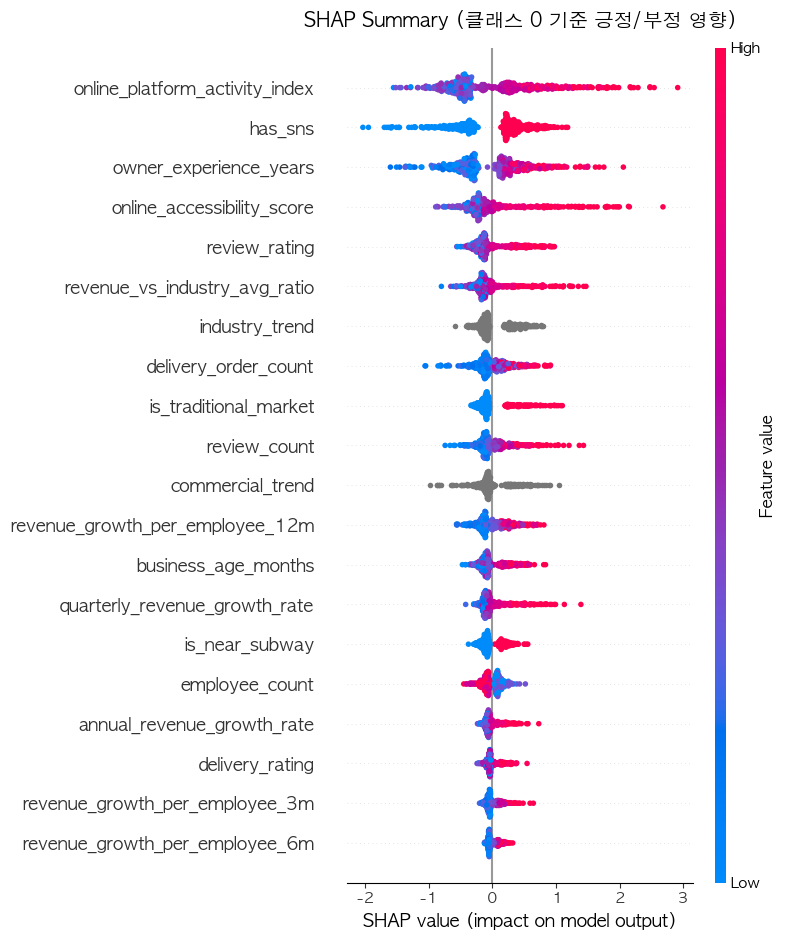

In [17]:
# ── 8. Summary Plot (특정 클래스 기준 긍정/부정 영향 확인) ────────────────────────
import shap
import numpy as np
import matplotlib.pyplot as plt

# 1. 원래 수치 배열(numpy) 안전하게 추출
if isinstance(shap_values, shap.Explanation):
    shap_raw = shap_values.values
elif isinstance(shap_values, list):
    shap_raw = np.array(shap_values)
else:
    shap_raw = shap_values

# [중요] 긍정/부정 방향을 보려면 '절댓값(abs)'을 취하지 않습니다.
# 여러 클래스가 섞이면 방향이 상쇄되므로 분석하고자 하는 특정 클래스를 선택합니다.
# (예: 앞서 Force Plot에서 사용한 predicted_class 또는 S등급 인덱스)
target_class = 0 

# 2. 구조(Shape)를 확인하여 '특정 클래스'의 SHAP 값만 추출 -> (샘플 수, 피처 수)
if shap_raw.ndim == 3:
    if shap_raw.shape[2] == X_sample.shape[1]: # (클래스, 샘플, 피처)
        shap_target = shap_raw[target_class, :, :]
    else: # (샘플, 피처, 클래스)
        shap_target = shap_raw[:, :, target_class]
else:
    shap_target = shap_raw # 이미 2차원인 경우

# 3. Summary Plot (Dot Plot) 시각화
plt.figure(figsize=(12, 10))
shap.summary_plot(
    shap_target,
    X_sample,
    plot_type='dot', # 기본값이 'dot'이며, 생략해도 됩니다.
    max_display=20,
    show=False,
)
plt.title(f'SHAP Summary (클래스 {target_class} 기준 긍정/부정 영향)', fontsize=14, pad=15)
plt.tight_layout()
plt.show()